# Задания для практических занятий и самостоятельной работы к главе 2
# Вариант 1
# Уравнение: (0,2x)^3 = cos x

## Задание 1:
### Отделить корни заданного уравнения, пользуясь графическим методом

In [1]:
from numpy import *
import matplotlib.pyplot as plt
from tabulate import tabulate
from scipy.optimize import root_scalar

Графический метод
Уравнение: (0.2x)^3 = cos(x)


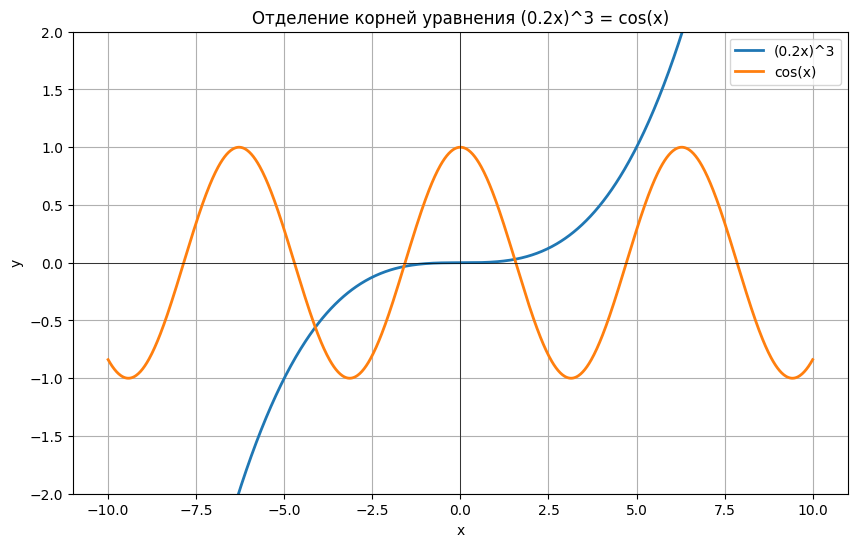


Интервалы, содержащие корни:
----------------------------------------
Корень на [-4.13; -4.11]
Корень на [-1.61; -1.59]
Корень на [1.53; 1.55]


In [2]:
print("Графический метод")
print("Уравнение: (0.2x)^3 = cos(x)")

# Задаем диапазон x
x = linspace(-10, 10, 1000)

y1 = (0.2 * x)**3
y2 = cos(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y1, label='(0.2x)^3', linewidth=2)
plt.plot(x, y2, label='cos(x)', linewidth=2)
plt.grid(True)
plt.legend()
plt.title('Отделение корней уравнения (0.2x)^3 = cos(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.ylim(-2, 2) # Ограничиваем ось y для наглядности
plt.show()

# Находим интервалы, где функции пересекаются
print("\nИнтервалы, содержащие корни:")
print("-" * 40)
for i in range(len(x)-1):
    if (y1[i] - y2[i]) * (y1[i+1] - y2[i+1]) < 0:
        print(f"Корень на [{x[i]:.2f}; {x[i+1]:.2f}]")

## Задание 2:
### По методу половинного деления вычислить один корень заданного уравнения с точностью 10^-3

In [3]:
f = lambda x: (0.2 * x)**3 - cos(x)

a_start, b_start, eps = 1.0, 2.0, 0.001
a, b = a_start, b_start

# Вывод начального отрезка
print(f"Начальный отрезок: [{a_start}, {b_start}]")
print(f"Заданная точность: {eps}\n")

rows = []
n = 0

while b - a > eps:
    n += 1
    c = (a + b) / 2
    f_a = f(a)
    f_c = f(c)
    
    # Сохраняем данные текущей итерации
    rows.append([n, a, b, c, f_c])
    
    if f_a * f_c <= 0:
        b = c
    else:
        a = c

# Вывод таблицы
headers = ["n", "a", "b", "c (середина)", "f(c)"]
formats = (".0f", ".4f", ".4f", ".4f", ".4f")
print(tabulate(rows, headers=headers, tablefmt="grid", floatfmt=formats))

# Итоговый вывод
print(f"\nКоличество итераций: {n}")
print(f"Корень: {(a + b) / 2:.3f}")

Начальный отрезок: [1.0, 2.0]
Заданная точность: 0.001

+-----+--------+--------+----------------+---------+
|   n |      a |      b |   c (середина) |    f(c) |
+=====+========+========+================+=========+
|   1 | 1.0000 | 2.0000 |         1.5000 | -0.0437 |
+-----+--------+--------+----------------+---------+
|   2 | 1.5000 | 2.0000 |         1.7500 |  0.2211 |
+-----+--------+--------+----------------+---------+
|   3 | 1.5000 | 1.7500 |         1.6250 |  0.0885 |
+-----+--------+--------+----------------+---------+
|   4 | 1.5000 | 1.6250 |         1.5625 |  0.0222 |
+-----+--------+--------+----------------+---------+
|   5 | 1.5000 | 1.5625 |         1.5312 | -0.0108 |
+-----+--------+--------+----------------+---------+
|   6 | 1.5312 | 1.5625 |         1.5469 |  0.0057 |
+-----+--------+--------+----------------+---------+
|   7 | 1.5312 | 1.5469 |         1.5391 | -0.0026 |
+-----+--------+--------+----------------+---------+
|   8 | 1.5391 | 1.5469 |         1.5430 | 

## Задание 3:
### Используя метод простой итерации вычислить один корень заданного уравнения с точностью 10^-6

In [4]:
f = lambda x: (0.2 * x)**3 - cos(x)

def phi(x):
    val = (0.2 * x)**3
    if val > 1: val = 1
    if val < -1: val = -1
    return acos(val)

# Начальные данные
x0_start, eps = 1.5, 1e-6
x0 = x0_start

print(f"Начальное приближение x0: {x0_start}")
print(f"Заданная точность eps: {eps}\n")

rows = []
n = 0

while True:
    n += 1
    x1 = phi(x0)
    diff = abs(x1 - x0)
    
    rows.append([n, x1, f(x1), diff])
    
    if diff < eps:
        break
    x0 = x1

# Настройка заголовков и форматов вывода
headers = ["n", "x_n", "f(x_n)", "|x_n - x_{n-1}|"]
formats = (".0f", ".6f", ".2e", ".2e")

print(tabulate(rows, headers=headers, tablefmt="grid", floatfmt=formats))

print(f"\nКоличество итераций: {n}")
print(f"Итоговый корень: {rows[-1][1]:.6f}")

Начальное приближение x0: 1.5
Заданная точность eps: 1e-06

+-----+----------+-----------+-------------------+
|   n |      x_n |    f(x_n) |   |x_n - x_{n-1}| |
+=====+==========+===========+===================+
|   1 | 1.543793 |  2.43e-03 |          4.38e-02 |
+-----+----------+-----------+-------------------+
|   2 | 1.541358 | -1.39e-04 |          2.44e-03 |
+-----+----------+-----------+-------------------+
|   3 | 1.541497 |  7.93e-06 |          1.39e-04 |
+-----+----------+-----------+-------------------+
|   4 | 1.541489 | -4.53e-07 |          7.94e-06 |
+-----+----------+-----------+-------------------+
|   5 | 1.541489 |  2.58e-08 |          4.53e-07 |
+-----+----------+-----------+-------------------+

Количество итераций: 5
Итоговый корень: 1.541489


## Задание 4:
### Вычислить один корень заданного уравнения используя комбинированный метод хорд и касательных с точностью 10^-6

Интервал: [1.0, 2.0], Точность: 1e-06
+------------+---------------+-----------+-----------+
|   Итерация |   x (среднее) |      f(x) |   Разница |
+============+===============+===========+===========+
|          1 |      1.524070 | -1.84e-02 |  2.41e-02 |
+------------+---------------+-----------+-----------+
|          2 |      1.532004 | -1.00e-02 |  7.93e-03 |
+------------+---------------+-----------+-----------+
|          3 |      1.531976 | -1.00e-02 |  2.83e-05 |
+------------+---------------+-----------+-----------+
|          4 |      1.531976 | -1.00e-02 |  1.09e-07 |
+------------+---------------+-----------+-----------+

ИТОГ: x = 1.531976 | f(x) = -1.00e-02


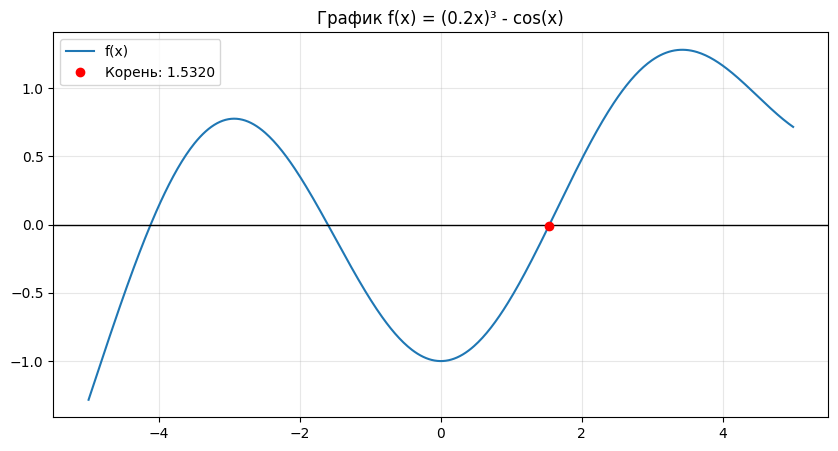

In [5]:
def find_root(a, b, eps=1e-6):
    f = lambda x: (0.2 * x)**3 - cos(x)
    f_p = lambda x: 0.024 * x**2 + sin(x)
    
    print(f"Интервал: [{a}, {b}], Точность: {eps}")
    
    rows = []
    x_prev = (a + b) / 2
    
    for i in range(1, 21):
        # Метод хорд
        denom = f(b) - f(a) #denom - denominator
        if abs(denom) < 1e-12: break
        x_chord = a - f(a) * (b - a) / denom
        
        # Метод касательных (выбор точки по условию сходимости)
        start_pt = a if f(a) * (0.048 * a + cos(a)) > 0 else b
        x_tang = start_pt - f(start_pt) / f_p(start_pt)
        
        x = (x_chord + x_tang) / 2
        diff = abs(x - x_prev)
        
        rows.append([i, x, f(x), diff])
        
        if diff < eps or abs(f(x)) < eps:
            break
            
        if f(a) * f(x) < 0: b = x
        else: a = x
        x_prev = x

    headers = ["Итерация", "x (среднее)", "f(x)", "Разница"]
    print(tabulate(rows, headers=headers, tablefmt="grid", floatfmt=(".0f", ".6f", ".2e", ".2e")))
    
    root = rows[-1][1]
    print(f"\nИТОГ: x = {root:.6f} | f(x) = {f(root):.2e}")
    return root

a, b = 1.0, 2.0
root = find_root(a, b)

# Визуализация
x_vals = linspace(-5, 5, 500)
f_plot = lambda x: (0.2 * x)**3 - cos(x)

plt.figure(figsize=(10, 5))
plt.plot(x_vals, f_plot(x_vals), label='f(x)')
plt.axhline(0, color='black', lw=1)
if root:
    plt.plot(root, f_plot(root), 'ro', label=f'Корень: {root:.4f}')
plt.title('График f(x) = (0.2x)³ - cos(x)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Задание 5:
### Вычислить один корень заданного уравнения с помощью инструментального пакета (SciPy) и точностью 10^-6

In [6]:
sol = root_scalar(f, bracket=[1.53, 1.55], method='brentq', xtol=1e-6)

print(f"Корень: x = {sol.root:.6f}")
print(f"Количество итераций: {sol.iterations}")

Корень: x = 1.541489
Количество итераций: 4


### Скриншот из онлайн аналога инструментального пакета Mathcad
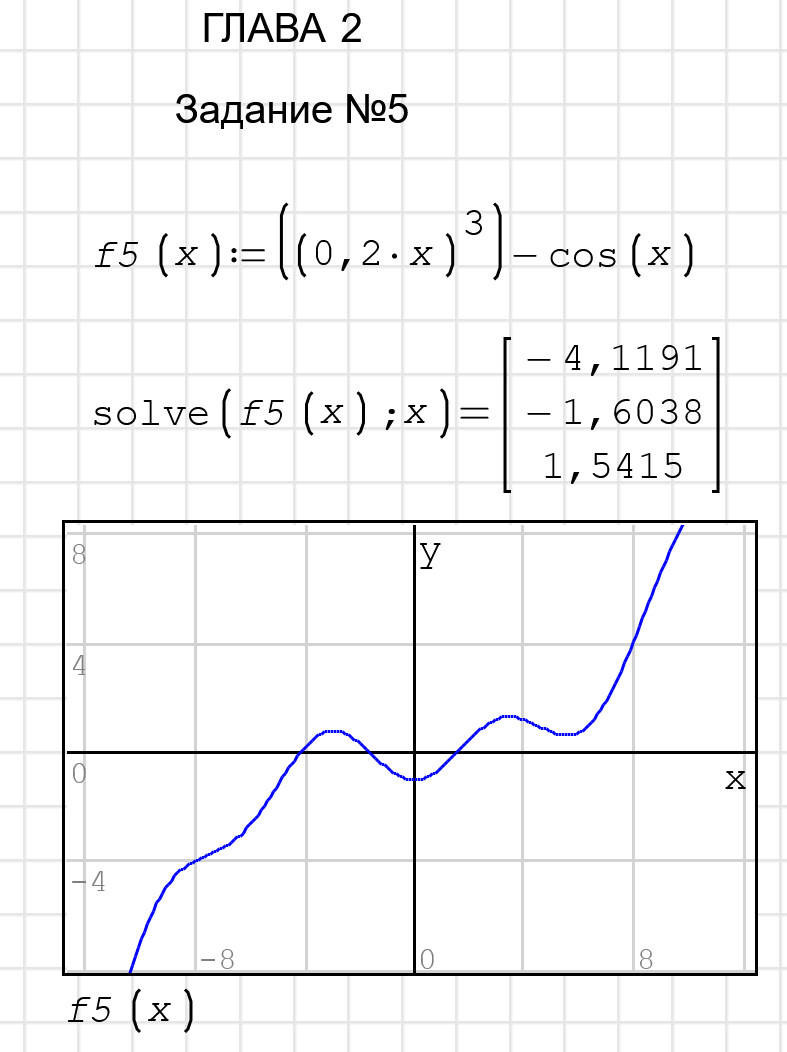

